### Problem Definition

1. *Problem Statement:*

    Perusahaan Fintech menghadapi risiko gagal bayar karena tidak semua nasabah mampu melunasi pinjaman.
    Ada dua jenis kesalahan yang perlu diminimalkan:
    - Menyetujui nasabah yang gagal bayar yang menyebapkan kerugian finansial langsung.
    - Menolak nasabah yang mampu bayar yang menyebapkan hilangnya potensi pendapatan.

2. *Objektive:*
    - Membangun model ML yang menghasilkan skor probabilitas gagal bayar.
    - Mengidentifikasi fitur-fitur yang paling berpengaruh untuk interpretabilitas stakeholder.

3. *Target variable:* 'loan_status' - Label 0 (Good) | Label 1 (Bad)

4. *Metrics:* Recall, ROC-AUC, F1-Score, Precision

In [1]:
# Setup/import libraries
import pandas as pd 
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE=42
np.random.seed(RANDOM_STATE) 

In [2]:
# Load & initial
df = pd.read_csv('loan_data_2007_2014.csv')

print('FINTECH CREDIT RISK MODELING - DATA OVERVIEW')
print('Dataset shape:', df.shape)
print('\nOverview 5 Sampel Data Teratas:')
df.head()

FINTECH CREDIT RISK MODELING - DATA OVERVIEW
Dataset shape: (466285, 75)

Overview 5 Sampel Data Teratas:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print('Info dataset:')
df.info()

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 

In [4]:
# Data quality
print('Jumlah Baris Duplikat:', df.duplicated().sum())
print('\nRingkasan Statistik Deskriptif:')
df.describe()

Jumlah Baris Duplikat: 0

Ringkasan Statistik Deskriptif:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [5]:
print('Distribusi target (loan_status):')
print(df['loan_status'].value_counts())

Distribusi target (loan_status):
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [6]:
missing = (df.isnull().sum().to_frame('Missing_Count'))
missing['Missing_Pct'] = (missing['Missing_Count'] / len(df) * 100)
missing = (missing.query('Missing_Count > 0').sort_values('Missing_Pct', ascending=False))
print('Analisis missing values:')
display(missing.head(25))

Analisis missing values:


,Missing_Count,Missing_Pct
inq_fi,466285,100.000000
open_rv_24m,466285,100.000000
max_bal_bc,466285,100.000000
all_util,466285,100.000000
inq_last_12m,466285,100.000000
annual_inc_joint,466285,100.000000
verification_status_joint,466285,100.000000
dti_joint,466285,100.000000
total_cu_tl,466285,100.000000
il_util,466285,100.000000


In [7]:
# Target definition
BAD_LOAN = [
    'Default',
    'Charged Off',
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off',
]
GOOD_LOAN = [
    'Current',
    'Fully Paid',
    'Does not meet the credit policy/ Status:Fully Paid'
]
VALID_STATUS = BAD_LOAN + GOOD_LOAN

df = df[df['loan_status'].isin(VALID_STATUS)].copy()
df['loan_status'] = df['loan_status'].isin(BAD_LOAN).astype(int)

print('Distribusi target setelah mapping:')
print(df['loan_status'].value_counts())

Distribusi target setelah mapping:
loan_status
0    408965
1     55332
Name: count, dtype: int64


In [8]:
# Data cleaning
LEAKAGE_COLS = [
    'Unnamed: 0', 'id', 'member_id', 'url', 'desc', 'title',
    'zip_code', 'emp_title', 'policy_code', 'pymnt_plan',
    'issue_d', 'funded_amnt', 'funded_amnt_inv', 'total_pymnt',
    'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'out_prncp', 'out_prncp_inv', 'sub_grade'
]
df.drop(columns=LEAKAGE_COLS, errors='ignore', inplace=True)
print('Ukuran dataset setelah di drop:', df.shape)

Ukuran dataset setelah di drop: (464297, 48)


In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers = []
for col in num_cols:
    if df[col].nunique() > 2:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        if outlier_count > 0:
            pct = round((outlier_count / len(df)) * 100, 2)
            outliers.append((col, outlier_count, pct))
outliers.sort(key=lambda x: x[1], reverse=True)

print('Jumlah outliers per column:')
for col, count, pct in outliers:
    print(f'{col}: {count} outlier ({pct}%)')

Jumlah outliers per column:
delinq_2yrs: 83003 outlier (17.88%)
pub_rec: 61200 outlier (13.18%)
tot_coll_amt: 49750 outlier (10.72%)
inq_last_6mths: 35396 outlier (7.62%)
revol_bal: 22633 outlier (4.87%)
total_rev_hi_lim: 21533 outlier (4.64%)
annual_inc: 19177 outlier (4.13%)
tot_cur_bal: 12264 outlier (2.64%)
installment: 11616 outlier (2.5%)
open_acc: 10400 outlier (2.24%)
total_acc: 8626 outlier (1.86%)
int_rate: 4904 outlier (1.06%)
collections_12_mths_ex_med: 3914 outlier (0.84%)
acc_now_delinq: 1728 outlier (0.37%)
mths_since_last_major_derog: 388 outlier (0.08%)
mths_since_last_delinq: 89 outlier (0.02%)
dti: 28 outlier (0.01%)
revol_util: 19 outlier (0.0%)


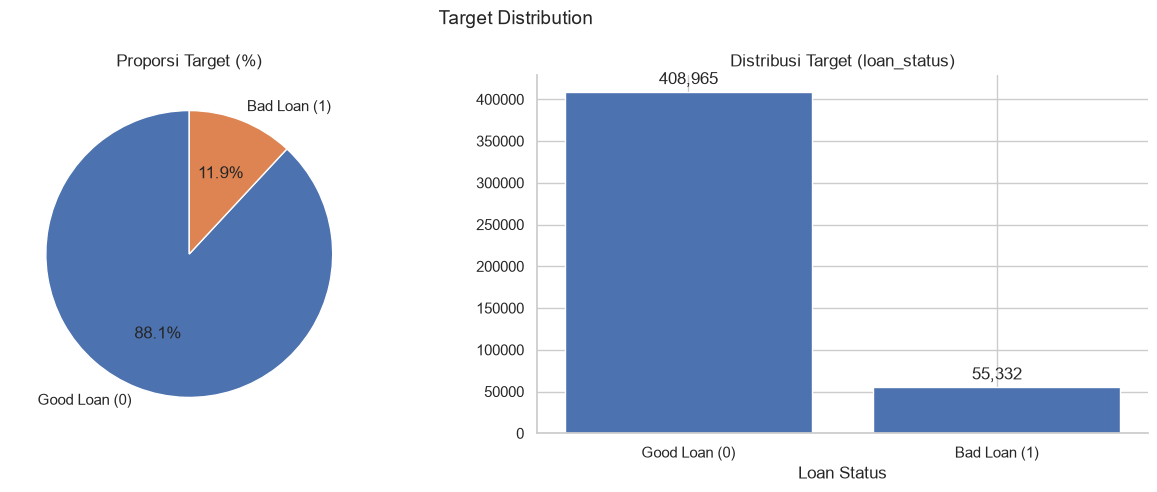

Imbalance Ratio (Good:Bad) = 7.39:1


In [10]:
counts = df['loan_status'].value_counts().sort_index()
labels = ['Good Loan (0)', 'Bad Loan (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Proporsi Target (%)')

bars = axes[1].bar(labels, counts.values)
axes[1].set_xlabel('Loan Status')
axes[1].set_title('Distribusi Target (loan_status)')
axes[1].spines[['top', 'right']].set_visible(False)

axes[1].bar_label(bars, labels=[f'{x:,}' for x in counts], padding=3)

plt.suptitle('Target Distribution', fontsize=14)
plt.tight_layout()
plt.show()
print(f'Imbalance Ratio (Good:Bad) = {counts[0]/counts[1]:.2f}:1')

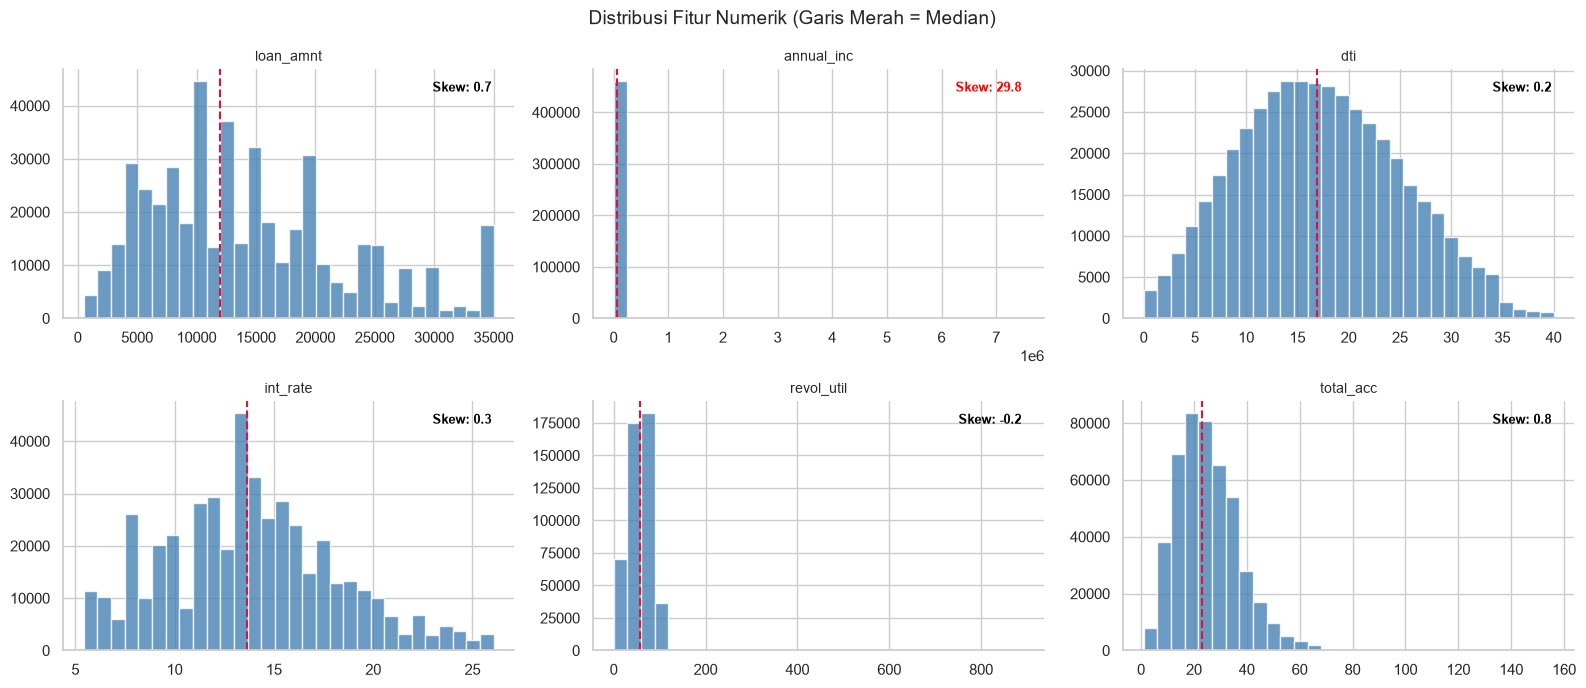

In [11]:
selected_num = [
    'loan_amnt',
    'annual_inc',
    'dti',
    'int_rate',
    'revol_util',
    'total_acc',
]

top_num_cols = [col for col in selected_num if col in df.columns]

N_COLS_GRID = 3
n_rows_grid = (len(top_num_cols) + N_COLS_GRID - 1) // N_COLS_GRID

fig, axes = plt.subplots(n_rows_grid, N_COLS_GRID, figsize=(16, n_rows_grid * 3.5))
axes_flat = axes.flatten()

for i, col in enumerate(top_num_cols):
    ax = axes_flat[i]
    data = df[col].dropna()

    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    median_val = data.median()
    ax.axvline(median_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')

    skew_val = data.skew()
    skew_color = 'red' if abs(skew_val) > 1 else 'black'
    ax.text(
        0.95, 0.95, f'Skew: {skew_val:.1f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color=skew_color, weight='bold',
    )

for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle('Distribusi Fitur Numerik (Garis Merah = Median)', fontsize=14)
plt.tight_layout()
plt.show()

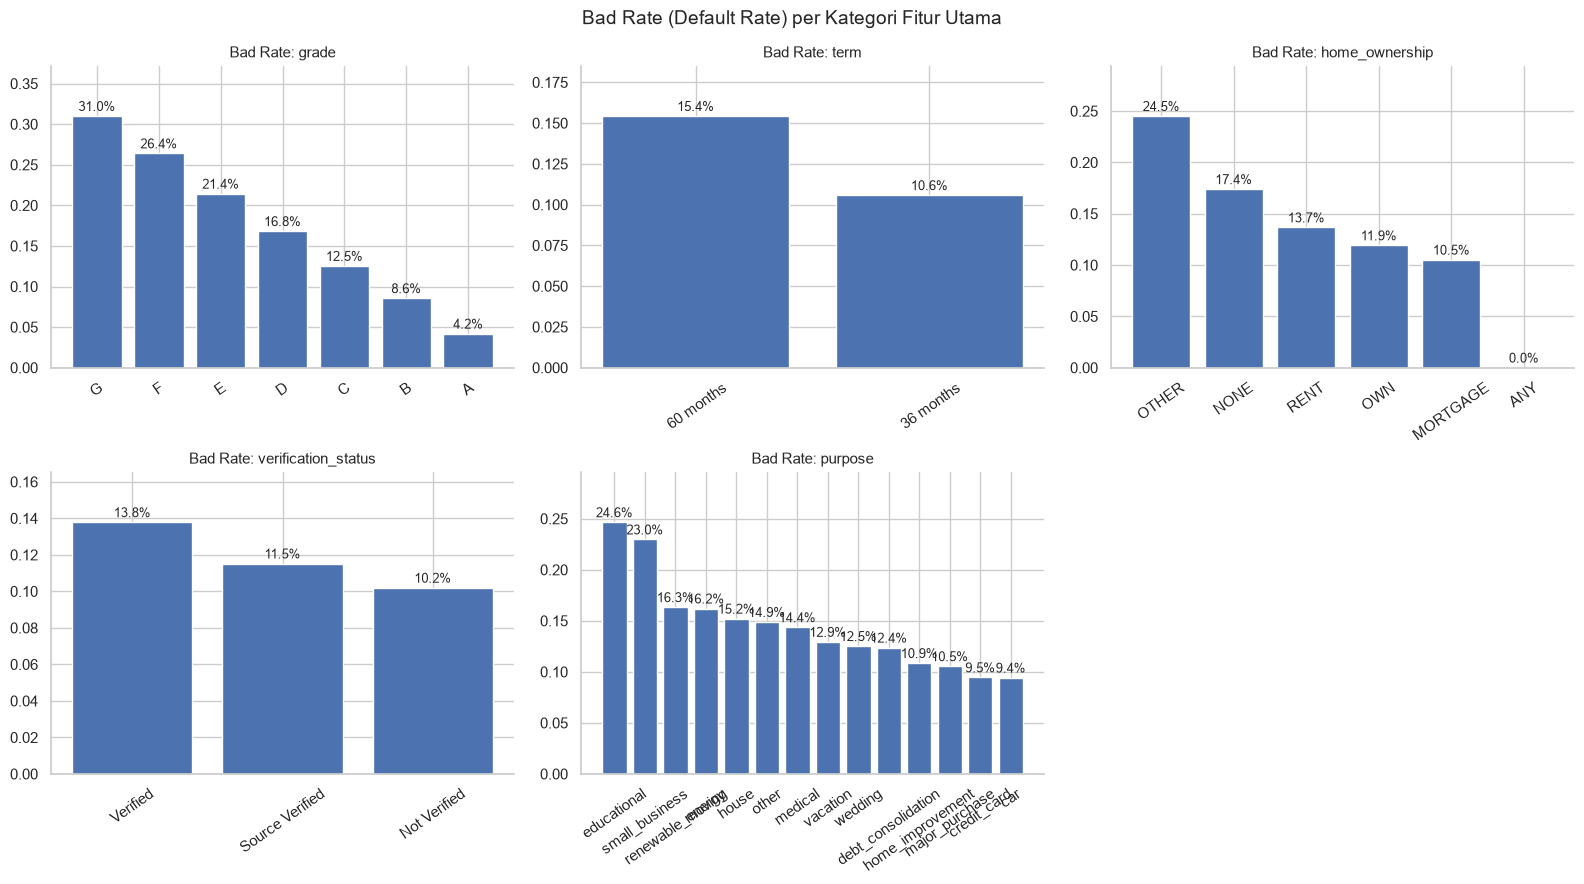

In [12]:
cat_cols = [
    col for col in ['grade', 'term', 'home_ownership', 'verification_status', 'purpose']
    if col in df.columns
]

if cat_cols:
    n_cats = len(cat_cols)
    ncols = 3
    nrows = (n_cats + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4.5))
    axes = axes.flatten()

    for ax, col in zip(axes, cat_cols):
        default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
        bars = ax.bar(default_rate.index.astype(str), default_rate.values)

        ax.set_title(f'Bad Rate: {col}', fontsize=11)
        ax.tick_params(axis="x", rotation=35)
        y_max = default_rate.max() if default_rate.max() > 0 else 0.1
        ax.set_ylim(0, y_max * 1.2)
        ax.spines[["top", "right"]].set_visible(False)

        for bar, val in zip(bars, default_rate.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + y_max * 0.02,
                f"{val:.1%}",
                ha="center", fontsize=9,
            )

    for j in range(len(cat_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Bad Rate (Default Rate) per Kategori Fitur Utama', fontsize=14)
    plt.tight_layout()
    plt.show()

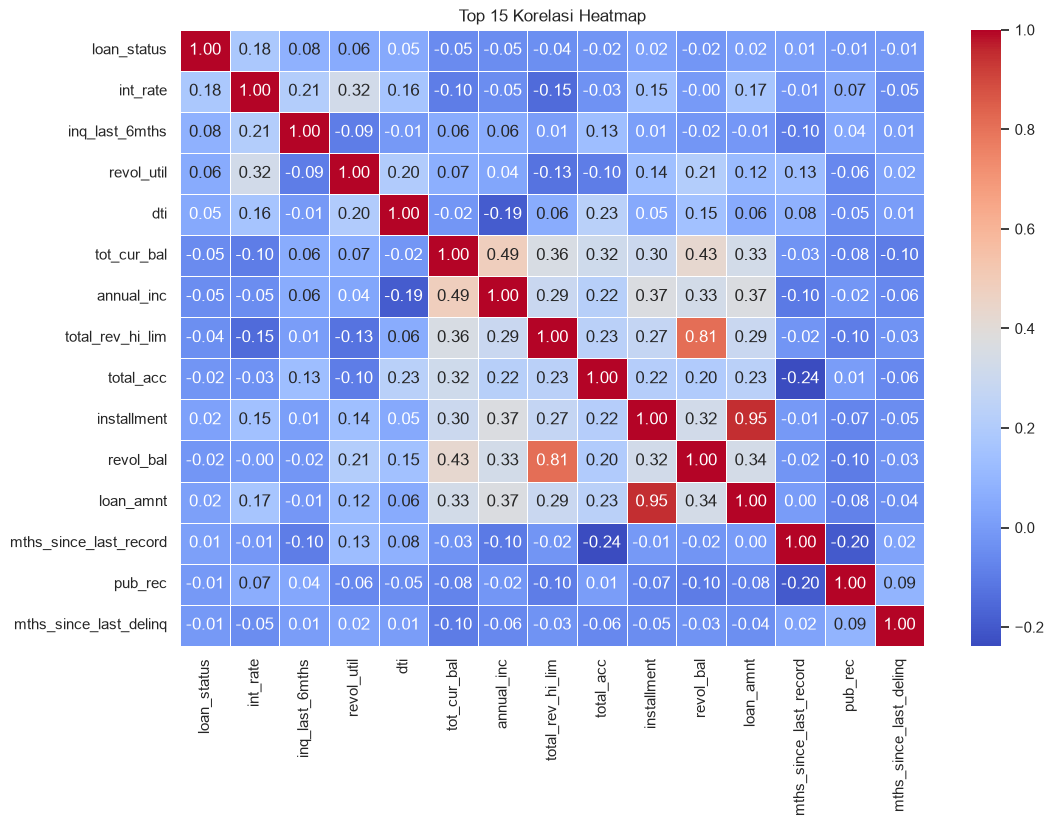

In [13]:
num_cols = df.select_dtypes(include=[np.number])
corr     = num_cols.corr()['loan_status'].abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 8))
sns.heatmap(
    num_cols[corr.index].corr(),
    cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5
)
plt.title('Top 15 Korelasi Heatmap')
plt.show()

In [14]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_raw = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

train_ratio = y_train.mean()
test_ratio = y_test.mean()

print('DATA SPLIT')
print(f'Train shape : {X_train_raw.shape}')
print(f'Test shape  : {X_test_raw.shape}')
print(f'Train Bad Rate  : {train_ratio:.2%}')
print(f'Test Bad Rate   : {test_ratio:.2%}')

n_good = (y_train == 0).sum()
n_bad = (y_train == 1).sum()
scale_pos_weight = n_good / n_bad

DATA SPLIT
Train shape : (371437, 47)
Test shape  : (92860, 47)
Train Bad Rate  : 11.92%
Test Bad Rate   : 11.92%


In [15]:
# Feature engineering
def compute_fe_stats(df):
    stats = {
        'annual_inc_median': df['annual_inc'].median(),
        'total_rev_hi_lim_median': df['total_rev_hi_lim'].median(),
        'total_acc_median': df['total_acc'].median(),
    }
    earliest = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
    snapshot = pd.Timestamp('2014-12-31')
    credit_history_age = (snapshot - earliest).dt.days.div(365.25).clip(lower=0)
    stats['credit_history_age_median'] = credit_history_age.median()

    return stats


def feature_enginering(df, stats):
    df = df.copy()
    EPS = 1e-6

    annual_income = (
        df['annual_inc'].fillna(stats['annual_inc_median']).clip(lower=0)
    )
    monthly_income = annual_income / 12

    df['loan_income_ratio'] = (
        df['loan_amnt'] / (monthly_income + EPS)
    )
    df['installment_income_ratio'] = (
        df['installment'] / (monthly_income + EPS)
    )

    total_rev_limit = (
        df['total_rev_hi_lim'].fillna(stats['total_rev_hi_lim_median'])
    )
    df['revol_bal_ratio'] = (
        df['revol_bal'] / (total_rev_limit + EPS)
    ).clip(upper=5)

    df['earliest_cr_line'] = pd.to_datetime(
        df['earliest_cr_line'], format='%b-%y', errors='coerce'
    )
    snapshot = pd.Timestamp('2014-12-31')
    df['credit_history_age'] = (
        (snapshot - df['earliest_cr_line']).dt.days.div(365.25)
    )
    df['credit_history_age'] = (
        df['credit_history_age'].clip(lower=0).fillna(stats['credit_history_age_median'])
    )

    df['has_delinq'] = (
        df['mths_since_last_delinq'].notna().astype(int)
    )

    total_balance = df['tot_cur_bal'].fillna(0)
    df['credit_income_ratio'] = total_balance / (annual_income + EPS)

    total_account = (
        df['total_acc'].fillna(stats['total_acc_median']).clip(lower=1)
    )
    inquiry = df['inq_last_6mths'].fillna(0)
    df['inq_ratio'] = inquiry / total_account

    if 'earliest_cr_line' in df.columns:
        df.drop(columns=['earliest_cr_line'], inplace=True)

    return df

fe_stats = compute_fe_stats(X_train_raw)
X_train = feature_enginering(X_train_raw, fe_stats)
X_test = feature_enginering(X_test_raw, fe_stats)

print('Feature engineering selesai.')
engineered_cols = [
    'loan_income_ratio',
    'installment_income_ratio',
    'revol_bal_ratio',
    'credit_history_age',
    'has_delinq',
    'credit_income_ratio',
    'inq_ratio',
]
print(X_train[engineered_cols].describe().T)

Feature engineering selesai.
                             count       mean       std       min        25%  \
loan_income_ratio         371437.0   2.627092  1.329563  0.009474   1.588235   
installment_income_ratio  371437.0   0.080169  0.040230  0.000289   0.049171   
revol_bal_ratio           371437.0   0.575628  0.326777  0.000000   0.378433   
credit_history_age        371437.0  17.173230  7.122502  0.000000  12.331280   
has_delinq                371437.0   0.463266  0.498649  0.000000   0.000000   
credit_income_ratio       371437.0   1.544244  1.568811  0.000000   0.310085   
inq_ratio                 371437.0   0.037437  0.062531  0.000000   0.000000   

                                50%        75%        max  
loan_income_ratio          2.470588   3.583333  13.440000  
installment_income_ratio   0.075251   0.107206   0.435456  
revol_bal_ratio            0.569091   0.751233   5.000000  
credit_history_age        15.835729  20.835044  45.995893  
has_delinq                 0.0

In [16]:
CAT_COLS = [c for c in ['grade', 'term', 'home_ownership', 'verification_status', 'purpose'] if c in X_train.columns]
NUM_COLS = X_train.select_dtypes(include='number').columns.tolist()

print(f'Jumlah fitur kategorikal: {len(CAT_COLS)}')
print(f'Jumlah fitur numerik    : {len(NUM_COLS)}')

Jumlah fitur kategorikal: 5
Jumlah fitur numerik    : 44


In [17]:
# Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), NUM_COLS),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), CAT_COLS),
], remainder='drop')

baseline_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        solver='liblinear',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(
    X_train, y_train
)

print('Baseline model berhasil di training.')

Baseline model berhasil di training.


In [18]:
# Model training
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])
pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=1
    ))
])
pipe_lgb = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        random_state=RANDOM_STATE,
        is_unbalance=True,
        verbose=-1,
        n_jobs=1
    ))
])

models = {
    'Logistic Regression': pipe_lr,
    'XGBoost': pipe_xgb,
    'LightGBM': pipe_lgb
}
metrics = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = []
for name, pipeline in models.items():
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metrics,
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Recall': cv_results['test_recall'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'F1': cv_results['test_f1'].mean(),
        'ROC-AUC': cv_results['test_roc_auc'].mean()
    })

comparison = (
    pd.DataFrame(results)
    .sort_values('ROC-AUC', ascending=False)
)
print(comparison)

TOP_N_CANDIDATES = 2
top_candidates = comparison['Model'].head(TOP_N_CANDIDATES).tolist()
print(f'\nTop {TOP_N_CANDIDATES} kandidat terpilih untuk hyperparameter tuning: {top_candidates}')

                 Model    Recall  Precision        F1   ROC-AUC
2             LightGBM  0.659829   0.189865  0.294878  0.694873
1              XGBoost  0.608842   0.193004  0.293096  0.684892
0  Logistic Regression  0.645687   0.185872  0.288650  0.680394

Top 2 kandidat terpilih untuk hyperparameter tuning: ['LightGBM', 'XGBoost']


In [19]:
# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

SEARCH_CONFIGS = {
    'Logistic Regression': {
        'pipeline': pipe_lr,
        'params': {'model__C': [0.01, 0.1, 1, 10]},
        'n_iter': 4,
    },
    'XGBoost': {
        'pipeline': pipe_xgb,
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0],
            'model__gamma': [0, 0.1, 0.2],
            'model__reg_lambda': [1, 3, 5],
        },
        'n_iter': 15,
    },
    'LightGBM': {
        'pipeline': pipe_lgb,
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__num_leaves': [15, 31, 63],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0],
            'model__min_child_samples': [10, 20, 30],
            'model__reg_alpha': [0, 0.5, 1],
            'model__reg_lambda': [0, 1, 3],
        },
        'n_iter': 15,
    },
}

SEARCH_CONFIGS = {name: cfg for name, cfg in SEARCH_CONFIGS.items() if name in top_candidates}
print(f'Model yang akan di-tuning: {list(SEARCH_CONFIGS.keys())}')

tuned_models = {}
tuning_results = []

for name, config in SEARCH_CONFIGS.items():
    search = RandomizedSearchCV(
        estimator=config['pipeline'],
        param_distributions=config['params'],
        n_iter=config['n_iter'],
        scoring='roc_auc',
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    search.fit(
        X_train,
        y_train,
    )

    tuned_models[name] = search.best_estimator_

    tuning_results.append({
        'Model': name,
        'Best CV ROC-AUC': search.best_score_,
        'Best Parameters': search.best_params_,
    })

tuning = pd.DataFrame(tuning_results).sort_values('Best CV ROC-AUC', ascending=False)
print(tuning)

Model yang akan di-tuning: ['XGBoost', 'LightGBM']
      Model  Best CV ROC-AUC  \
1  LightGBM         0.695602   
0   XGBoost         0.694768   

                                     Best Parameters  
1  {'model__subsample': 0.8, 'model__reg_lambda':...  
0  {'model__subsample': 0.8, 'model__reg_lambda':...  


In [20]:
# Model selection
model_selection_df = tuning.reset_index(drop=True)

best_name = model_selection_df.iloc[0]['Model']
best_model = tuned_models[best_name]

print(model_selection_df[['Model', 'Best CV ROC-AUC']])
print('\nModel terpilih:', best_name)

      Model  Best CV ROC-AUC
0  LightGBM         0.695602
1   XGBoost         0.694768

Model terpilih: LightGBM


In [21]:
# Probability calibration
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method='sigmoid',
    cv=5,
)

calibrated_model.fit(
    X_train,
    y_train,
)
print(f'Probability calibration {best_name} selesai.')

Probability calibration LightGBM selesai.


In [22]:
# Threshold optimization
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score, 
)

COST_FN = 10_000_000
COST_FP = 1_500_000

oof_prob = cross_val_predict(
    calibrated_model,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

thresholds = np.arange(
    0.05,
    0.86,
    0.01,
)

threshold_records = []

for threshold in thresholds:
    oof_pred = (
        oof_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        oof_pred,
        labels=[0, 1],
    ).ravel()

    expected_cost = (
        fn * COST_FN
        + fp * COST_FP
    )

    threshold_records.append({
        'threshold': threshold,
        'recall': recall_score(
            y_train,
            oof_pred,
            zero_division=0,
        ),
        'precision': precision_score(
            y_train,
            oof_pred,
            zero_division=0,
        ),
        'f1': f1_score(
            y_train,
            oof_pred,
            zero_division=0,
        ),
        'f2': fbeta_score(
            y_train,
            oof_pred,
            beta=2,
            zero_division=0,
        ),
        'approval_rate': 1 - oof_pred.mean(),
        'expected_cost': expected_cost,
        'false_negative': fn,
        'false_positive': fp,
        'true_negative': tn,
        'true_positive': tp,
    })

threshold_df = pd.DataFrame(
    threshold_records
)

optimal_index = threshold_df[
    'expected_cost'
].idxmin()

optimal_threshold = float(
    threshold_df.loc[
        optimal_index,
        'threshold',
    ]
)

optimal_threshold_result = threshold_df.loc[
    optimal_index
]

print(
    f'Selected Model: {best_name}'
)

print(
    f'Optimal Threshold: {optimal_threshold:.2f}'
)

print(
    f'OOF Recall:'
    f'{optimal_threshold_result["recall"]:.2%}'
)

print(
    f'OOF Precision:'
    f'{optimal_threshold_result["precision"]:.2%}'
)

print(
    f'OOF Approval Rate:'
    f'{optimal_threshold_result["approval_rate"]:.2%}'
)

print(
    'Estimated OOF Expected Cost:'
    f'Rp {optimal_threshold_result["expected_cost"]:,.0f}'
)

Selected Model: LightGBM
Optimal Threshold: 0.13
OOF Recall:62.55%
OOF Precision:19.71%
OOF Approval Rate:62.19%
Estimated OOF Expected Cost:Rp 334,922,000,000


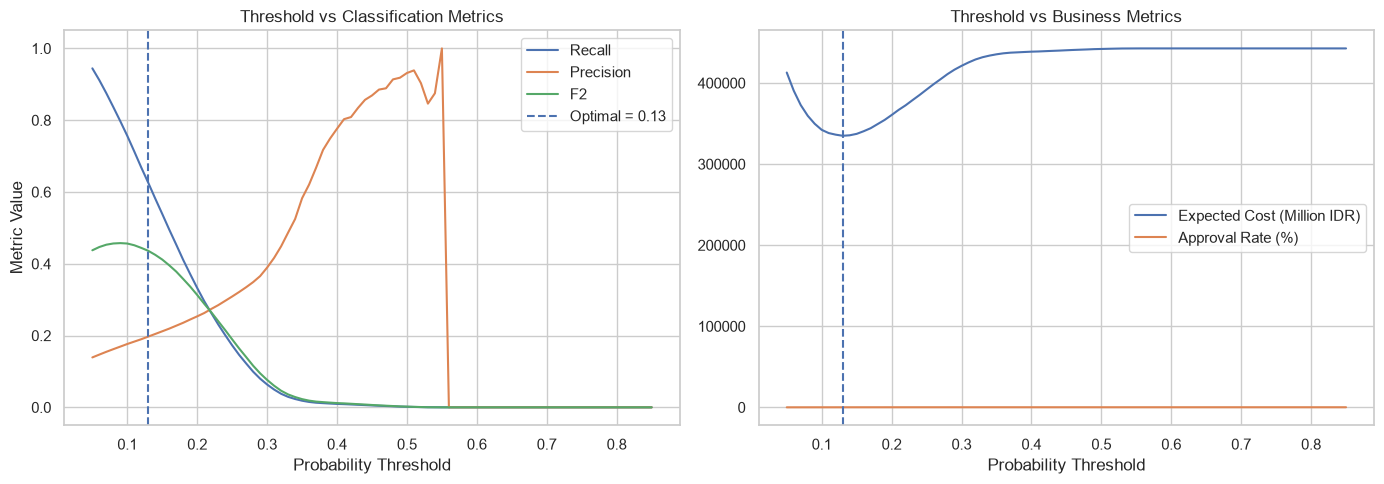

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    label='Recall',
)
axes[0].plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    label='Precision',
)
axes[0].plot(
    threshold_df['threshold'],
    threshold_df['f2'],
    label='F2',
)
axes[0].axvline(
    optimal_threshold,
    linestyle='--',
    label=f'Optimal = {optimal_threshold:.2f}',
)
axes[0].set_title('Threshold vs Classification Metrics')
axes[0].set_xlabel('Probability Threshold')
axes[0].set_ylabel('Metric Value')
axes[0].legend()
axes[1].plot(
    threshold_df['threshold'],
    threshold_df['expected_cost'] / 1_000_000,
    label='Expected Cost (Million IDR)',
)
axes[1].plot(
    threshold_df['threshold'],
    threshold_df['approval_rate'] * 100,
    label='Approval Rate (%)',
)
axes[1].axvline(
    optimal_threshold,
    linestyle='--',
)
axes[1].set_title('Threshold vs Business Metrics')
axes[1].set_xlabel('Probability Threshold')
axes[1].legend()
plt.tight_layout()
plt.show()

In [24]:
# Final test evaluation
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    brier_score_loss,
)

test_prob = calibrated_model.predict_proba(X_test)[:, 1]

test_pred = (test_prob >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred,
    labels=[0, 1],
).ravel()

precision_values, recall_values, _ = (
    precision_recall_curve(y_test, test_prob)
)

pr_auc = auc(
    recall_values, precision_values,
)

final_metrics = {
    'Recall': recall_score(
        y_test,
        test_pred,
        zero_division=0,
    ),
    'Precision': precision_score(
        y_test,
        test_pred,
        zero_division=0,
    ),
    'F1-Score': f1_score(
        y_test,
        test_pred,
        zero_division=0,
    ),
    'ROC-AUC': roc_auc_score(
        y_test,
        test_prob,
    ),
    'PR-AUC': pr_auc,
    "Brier Score": brier_score_loss(
        y_test,
        test_prob,
    ),
    'Approval Rate': 1 - test_pred.mean(),
    'Expected Cost': (
        fn * COST_FN
        + fp * COST_FP
    ),
}

final_results = pd.DataFrame(
    [final_metrics]
)

display(final_results)

print(
    f'TN={tn:,}, FP={fp:,},'
    f'FN={fn:,}, TP={tp:,}'
)

,Recall,Precision,F1-Score,ROC-AUC,PR-AUC,Brier Score,Approval Rate,Expected Cost
0,0.634104,0.199381,0.303372,0.701077,0.248966,0.098742,0.620999,82755500000


TN=53,617, FP=28,177,FN=4,049, TP=7,017


,Risk Tier,Total_Customers,Total_Bad_Loan,Actual_Bad_Rate,Average_PD
0,1. Low Risk,64769,5018,0.077475,0.078062
1,2. Medium Risk,27703,5813,0.209833,0.211943
2,3. High Risk,388,235,0.605670,0.403951


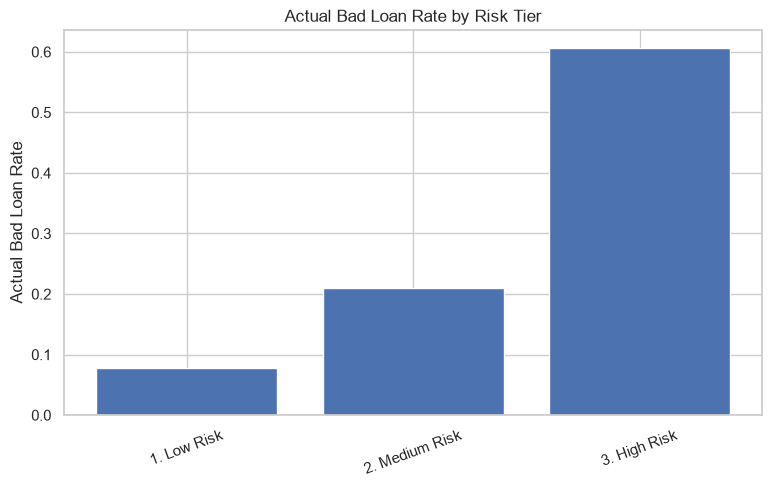

In [25]:
# Risk analysis
risk_analysis = pd.DataFrame({
    'Actual': y_test.to_numpy(),
    'Probability': test_prob,
})

RISK_THRESHOLDS = {
    'low': 0.15,
    'medium': 0.35,
    'high': 0.60,
}

def assign_risk_tier(probability):
    if probability < RISK_THRESHOLDS['low']:
        return '1. Low Risk'
    if probability < RISK_THRESHOLDS['medium']:
        return '2. Medium Risk'
    if probability < RISK_THRESHOLDS['high']:
        return '3. High Risk'
    return '4. Critical Risk'

risk_analysis['Risk Tier'] = (
    risk_analysis['Probability']
    .apply(assign_risk_tier)
)

tier_summary = (
    risk_analysis
    .groupby('Risk Tier')
    .agg(
        Total_Customers=('Actual', 'count'),
        Total_Bad_Loan=('Actual', 'sum'),
        Actual_Bad_Rate=('Actual', 'mean'),
        Average_PD=('Probability', 'mean'),
    )
    .reset_index()
)

display(tier_summary)

plt.figure(figsize=(9, 5))
plt.bar(
    tier_summary['Risk Tier'],
    tier_summary['Actual_Bad_Rate'],
)
plt.title('Actual Bad Loan Rate by Risk Tier')
plt.ylabel('Actual Bad Loan Rate')
plt.xticks(rotation=20)
plt.show()

In [26]:
# Model explainability
import shap

base_model = best_model
preprocessor_fitted = base_model.named_steps['prep']
model_fitted = base_model.named_steps['model']

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

X_test_transformed = (
    preprocessor_fitted
    .transform(X_test)
)

if hasattr(
    X_test_transformed,
    'toarray',
):
    X_test_transformed = (
        X_test_transformed.toarray()
    )

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index,
)

sample_size = min(
    500,
    len(X_test_transformed),
)

X_shap_sample = (
    X_test_transformed
    .sample(
        sample_size,
        random_state=RANDOM_STATE,
    )
)

if isinstance(
    model_fitted,
    (
        XGBClassifier,
        LGBMClassifier,
    ),
):
    explainer = shap.TreeExplainer(
        model_fitted
    )
else:
    explainer = shap.LinearExplainer(
        model_fitted,
        X_shap_sample,
    )

shap_values = explainer.shap_values(
    X_shap_sample
)

if isinstance(
    shap_values,
    list,
):
    shap_values = shap_values[-1]

shap_values = np.asarray(
    shap_values
)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print(
    'SHAP analysis completed.'
)

SHAP analysis completed.


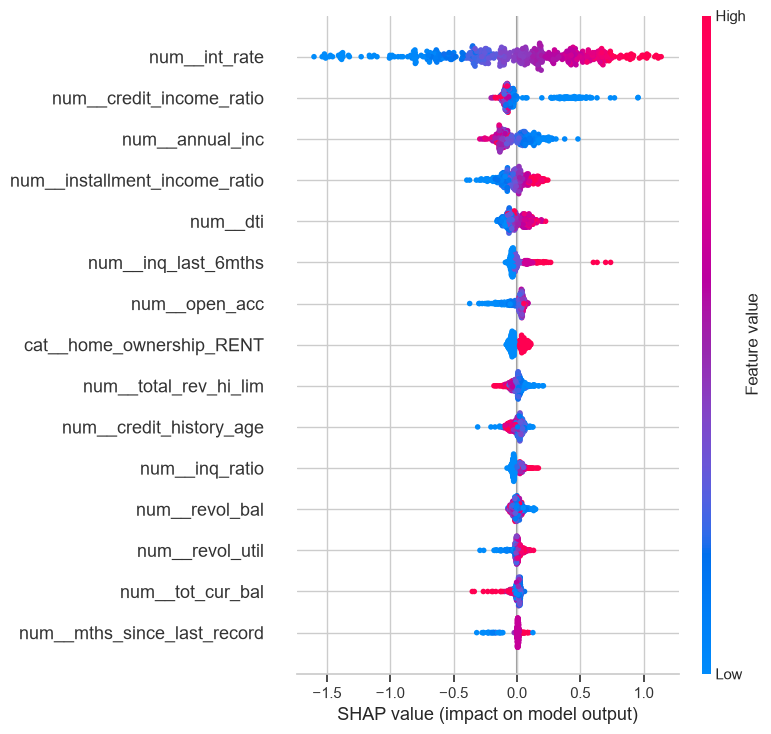

In [27]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type='dot',
    max_display=15,
)

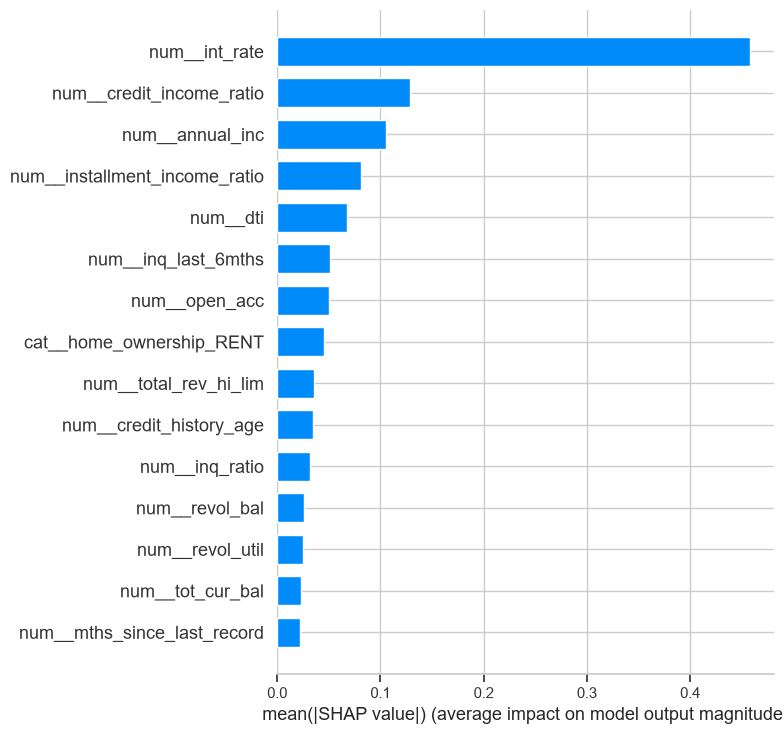

In [28]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type='bar',
    max_display=15,
)